The idea of this notebook is to selectively run the raw data from each source and process them into trajectories

# Controls

In [1]:
Mobile_Proccessing = True
WikiLoc_Proccessing = True

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import csv
import cartopy.crs as ccrs
from shapely.geometry import Point
from shapely.geometry import LineString
import shapely.wkt
import movingpandas as mpd
from shapely.geometry import Point
from datetime import timedelta
import trackintel as ti


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


# Static Vairables

In [3]:
MASK = gpd.read_file("Data/Banks_Mask_Buffered.gpkg").to_crs(epsg=2193)
SALT = 741

# Functions

In [4]:
def clean_and_mask_gps_points(geometry, user_id ,time = None, activity_id = None, elevation = None):
    geometry = geometry.to_crs(epsg=2193)

    def _as_pointwise(value):
        if isinstance(value, (pd.Series, list, tuple, np.ndarray)):
            return pd.Series(value).reset_index(drop=True)
        return value

    if time is not None:
        if pd.api.types.is_numeric_dtype(time):
            time = pd.to_datetime(time, unit='s', errors='coerce')
        else:
            time = pd.to_datetime(time, errors='coerce')

        # Keep timestamps timezone-naive for downstream movingpandas usage.
        if hasattr(time.dt, "tz") and time.dt.tz is not None:
            time = time.dt.tz_localize(None)
    
    user_id = _as_pointwise(user_id)
    time = _as_pointwise(time)
    elevation = _as_pointwise(elevation)

    if activity_id is not None:
        activity_id = _as_pointwise(activity_id)


    point_gdf = gpd.GeoDataFrame(
                                        geometry=geometry,  
                                        data={
                                            'time': time,
                                            'user_id': user_id,
                                            'activity_id': activity_id,
                                            'elevation': elevation
                                        })

    #Mask the GPS points using the provided mask
    masked_point_gdf = gpd.sjoin(point_gdf, MASK, how='inner', predicate='within')
    masked_point_gdf = masked_point_gdf.drop(columns=["index_right"])
    #Clean
    masked_point_gdf = masked_point_gdf.dropna(subset=["geometry", "time"])
   
    masked_point_gdf = masked_point_gdf.drop_duplicates(subset=["geometry", "time"])

    # Ensure `time` column is pandas datetime and timezone-naive (covers cases when reading back from GPKG)
    if "time" in masked_point_gdf.columns:
        masked_point_gdf["time"] = pd.to_datetime(masked_point_gdf["time"], errors="coerce")
        if hasattr(masked_point_gdf["time"].dt, "tz") and masked_point_gdf["time"].dt.tz is not None:
            masked_point_gdf["time"] = masked_point_gdf["time"].dt.tz_localize(None)
        masked_point_gdf = masked_point_gdf.dropna(subset=["time"]).copy()

    return masked_point_gdf
def form_trajectory(gps_point_gdf, source, activity_type=None, min_points=4, min_distance=50, outlier_vmax=12, gap_minutes=5):
    columns = [
        "user_id",
        "activity_id",
        "start_time",
        "end_time",
        "activity_type",
        "activity_class",
        "source",
        "n_points",
        "trajectory",
        "geometry"
    ]

    if gps_point_gdf is None or gps_point_gdf.empty:
        return pd.DataFrame(columns=columns)

    gps_point_gdf = gps_point_gdf.sort_values("time").copy()
    records = []

    def trajectory_geometry(traj):
        return traj.to_linestring()

    def trajectory_distance(traj):
        return trajectory_geometry(traj).length

    activity_type_defined = pd.notna(activity_type) and str(activity_type).strip() != ""

    def maybe_clean_outliers(traj):
        if len(traj.df) < 2:
            return traj
        if activity_type_defined:
            return mpd.OutlierCleaner(traj).clean(v_max=outlier_vmax)
        return traj

    # If there is a valid activity_id, split the activity into time-gap based trips.
    if gps_point_gdf["activity_id"].notnull().all():
        activity_id = gps_point_gdf["activity_id"].iloc[0]
        base_trajectory = mpd.Trajectory(
            gps_point_gdf,
            traj_id=activity_id,
            t="time",
            crs="EPSG:2193"
        )
        base_trajectory = maybe_clean_outliers(base_trajectory)
        trips = mpd.ObservationGapSplitter(base_trajectory).split(gap=timedelta(minutes=gap_minutes))

        for trip in trips:
            if activity_type_defined:
                trip = maybe_clean_outliers(trip)

            if trip.df.empty or len(trip.df) < min_points or trajectory_distance(trip) < min_distance:
                continue

            if "trip_id" in trip.df.columns:
                trip_activity_id = trip.df["trip_id"].iloc[0]
            else:
                trip_activity_id = trip.id

            # Classify the trip
            activity_class = classify_trip_activity(activity_type, trip.df)

            records.append({
                "user_id": trip.df["user_id"].iloc[0],
                "activity_id": trip_activity_id,
                "start_time": trip.get_start_time(),
                "end_time": trip.get_end_time(),
                "activity_type": activity_type,
                "activity_class": activity_class,
                "source": source,
                "n_points": len(trip.df),
                "trajectory": trip,
                "geometry": trajectory_geometry(trip)
            })
    else:
        unique_user_ids = gps_point_gdf["user_id"].dropna().unique()

        for base_user_id in unique_user_ids:
            user_gps_point_gdf = gps_point_gdf[gps_point_gdf["user_id"] == base_user_id].sort_values("time").copy()
            if len(user_gps_point_gdf) < 2:
                continue

            base_trajectory = mpd.Trajectory(
                user_gps_point_gdf,
                traj_id=base_user_id,
                t="time",
                crs="EPSG:2193"
            )
            base_trajectory = maybe_clean_outliers(base_trajectory)
            trips = mpd.ObservationGapSplitter(base_trajectory).split(gap=timedelta(minutes=gap_minutes))

            for trip in trips:
                if activity_type_defined:
                    trip = maybe_clean_outliers(trip)

                if trip.df.empty or len(trip.df) < min_points or trajectory_distance(trip) < min_distance:
                    continue

                if "trip_id" in trip.df.columns:
                    trip_activity_id = trip.df["trip_id"].iloc[0]
                else:
                    trip_activity_id = trip.id

                # Classify the trip
                activity_class = classify_trip_activity(activity_type, trip.df)

                records.append({
                    "user_id": trip.df["user_id"].iloc[0],
                    "activity_id": trip_activity_id,
                    "start_time": trip.get_start_time(),
                    "end_time": trip.get_end_time(),
                    "activity_type": activity_type,
                    "activity_class": activity_class,
                    "source": source,
                    "n_points": len(trip.df),
                    "trajectory": trip,
                    "geometry": trajectory_geometry(trip)
                })

    return pd.DataFrame(records, columns=columns)
def classify_trip_activity(activity_type, trajectory_data=None, counts_row=None):
    """
    Classify a trip into one of three activity classes: 'pedestrian', 'cycle', or 'other'.

    Priority order:
    1. If `activity_type` is provided, classify from the activity label only (no fallback).
    2. If not provided and `counts_row` is provided, classify from aggregated counts in that row.
    3. If not provided and `trajectory_data` is provided, use mobiML-style speed heuristics.
    """

    # Mapping of known activity types to classes
    activity_type_mapping = {
        # Pedestrian activities
        'walking': 'pedestrian',
        'hike': 'pedestrian',
        'hiking': 'pedestrian',
        'trail': 'pedestrian',
        'trekking': 'pedestrian',
        'walk': 'pedestrian',
        'scramble': 'pedestrian',
        'running': 'pedestrian',
        'trail_running': 'pedestrian',
        'fell_running': 'pedestrian',
        'fell-running': 'pedestrian',
        'parkrun': 'pedestrian',

        # Cycling activities
        'cycling': 'cycle',
        'cycle': 'cycle',
        'bike': 'cycle',
        'biking': 'cycle',
        'mountain_biking': 'cycle',
        'mountain-biking': 'cycle',
        'mtb': 'cycle',
        'downhill': 'cycle',
        'road_biking': 'cycle',
        'road-biking': 'cycle',
        'bmx': 'cycle',
        'gravel': 'cycle',
    }

    # Check if activity_type is defined
    activity_type_defined = pd.notna(activity_type)

    if activity_type_defined:
        activity_lower = activity_type.strip().lower()

        # Direct match
        if activity_lower in activity_type_mapping:
            return activity_type_mapping[activity_lower]

        # Partial matches
        for key, classification in activity_type_mapping.items():
            if key in activity_lower:
                return classification

        # If activity_type is provided but no match found, return 'other' (no fallback)
        return 'other'

    # Fallback: Use mobiML-based classification if trajectory data available
    if trajectory_data is not None and len(trajectory_data) > 0:
        return classify_trip_by_mobiml(trajectory_data)

    # Default fallback
    return 'other'


def classify_trip_by_mobiml(trajectory_data):
    """
    Classify a trip using mobiML-based features (speed, acceleration, etc.).

    This version is defensive: it will try to recover a usable `time` series
    if the dataframe lacks an explicit `time` column (e.g., when time is in
    the index or has a different name after reading from GPKG).
    """
    try:
        # Quick length check
        if len(trajectory_data) < 2:
            return 'other'

        # Work on a copy
        df = trajectory_data.copy()

        # Ensure there is a usable `time` column
        if 'time' not in df.columns:
            # If the index is a DatetimeIndex, bring it into a column
            if isinstance(df.index, pd.DatetimeIndex) or pd.api.types.is_datetime64_any_dtype(df.index):
                df = df.reset_index()
                # rename the first column (commonly 'index' or similar) to 'time'
                if 'time' not in df.columns:
                    df.rename(columns={df.columns[0]: 'time'}, inplace=True)
            else:
                # try to find any time-like column
                time_like = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower() or 'timestamp' in c.lower()]
                if time_like:
                    df['time'] = pd.to_datetime(df[time_like[0]], errors='coerce')
                else:
                    print("Warning: mobiML classification failed: no time column")
                    return 'other'

        # Coerce to datetime, drop invalid
        df['time'] = pd.to_datetime(df['time'], errors='coerce')
        if hasattr(df['time'].dt, 'tz') and df['time'].dt.tz is not None:
            df['time'] = df['time'].dt.tz_localize(None)
        df = df.dropna(subset=['time']).copy()

        # Must still have at least two points
        if len(df) < 2:
            return 'other'

        # Sort and compute diffs
        df = df.sort_values('time').copy()
        df['time_diff'] = df['time'].diff().dt.total_seconds()

        # Ensure geometry column exists
        if 'geometry' not in df.columns:
            print("Warning: mobiML classification failed: no geometry column")
            return 'other'

        df['distance'] = df.geometry.distance(df.geometry.shift())

        # Filter out invalid rows
        valid_data = df[(df['time_diff'] > 0) & (df['distance'] >= 0)].copy()
        if len(valid_data) < 2:
            return 'other'

        # Calculate speed (m/s)
        valid_data['speed'] = valid_data['distance'] / valid_data['time_diff']
        mean_speed = valid_data['speed'].mean()

        # Heuristic classification based on mean speed
        if mean_speed < 3:
            return 'pedestrian'
        elif 3 <= mean_speed < 10:
            return 'cycle'
        else:
            return 'other'

    except Exception as e:
        print(f"Warning: mobiML classification failed: {e}")
        return 'other'

def split_cpath(value):
    """Parse a cpath-like value into a list of string parts.

    Accepts lists, NaN, or comma-separated strings.
    """
    if isinstance(value, list):
        return [part for part in value if str(part).strip()]
    if pd.isna(value):
        return []
    return [part.strip() for part in str(value).split(",") if part.strip()]


def split_edge_ids(gdf, edges, cpath_col="cpath", edge_col="edge_ids", osmid_col="osmid", out_path=None):
    """Explode a cpath-style column into edge ids and map edge attributes."""
    df = gdf.copy()
    df[edge_col] = df[cpath_col].apply(split_cpath)
    df = df.explode(edge_col, ignore_index=True).dropna(subset=[edge_col])
    df[edge_col] = df[edge_col].astype(int)
    df[osmid_col] = edges.iloc[df[edge_col].to_numpy()][osmid_col].to_numpy()

    if out_path is not None:
        df.to_file(out_path, driver="GPKG")

    return df


# Mobile

## Cleaning

In [77]:
for i in range(34):
    print(f"Processing file {i+1}/34")

    gps_points = pd.read_csv(f"Data/Mobile/Download/1_{i+1}.tsv", sep="\t")
    
    geometry = gpd.points_from_xy(gps_points["Longitude of Visit"], gps_points["Latitude of Visit"],crs="EPSG:4326")
    geometry = geometry.to_crs(epsg=2193)
    user_id = gps_points["Hashed Device ID"]
    time = gps_points["Unix Timestamp of Visit"]

    masked_gps_points = clean_and_mask_gps_points(geometry, user_id, time)
    masked_gps_points.to_file(f"Data/Mobile/Cleaned/{i+1}.gpkg", driver="GPKG")

Processing file 1/34
Processing file 2/34
Processing file 3/34
Processing file 4/34
Processing file 5/34
Processing file 6/34
Processing file 7/34
Processing file 8/34
Processing file 9/34
Processing file 10/34
Processing file 11/34
Processing file 12/34
Processing file 13/34
Processing file 14/34
Processing file 15/34
Processing file 16/34
Processing file 17/34
Processing file 18/34
Processing file 19/34
Processing file 20/34
Processing file 21/34
Processing file 22/34
Processing file 23/34
Processing file 24/34
Processing file 25/34
Processing file 26/34
Processing file 27/34
Processing file 28/34
Processing file 29/34
Processing file 30/34
Processing file 31/34
Processing file 32/34
Processing file 33/34
Processing file 34/34


## Trajectory Formation and Classifying

In [81]:
trajectory_frames = []
total_trajectories = 0
for i in range(34):
    file_path = f"Data/Mobile/Cleaned/{i+1}.gpkg"
    print(f"[Mobile] Reading cleaned points from {file_path}")
    masked_gps_points = gpd.read_file(file_path).to_crs(epsg=2193)
    print(f"[Mobile]   points loaded: {len(masked_gps_points)}")
    trajectories = form_trajectory(masked_gps_points, source="Mobile", activity_type=None, gap_minutes=5)
    print(f"[Mobile]   trajectories formed: {len(trajectories)}")
    if not trajectories.empty:
        trajectory_frames.append(trajectories)
        total_trajectories += len(trajectories)
        print(f"[Mobile]   appended batch, running total: {total_trajectories}")
    else:
        print("[Mobile]   no valid trajectories in this file")

if trajectory_frames:
    trajectory_df = pd.concat(trajectory_frames, ignore_index=True)
else:
    trajectory_df = pd.DataFrame(columns=["user_id", "activity_id", "start_time", "end_time", "activity_type", "activity_class", "source", "n_points", "trajectory", "geometry"])

print(f"[Mobile] Total trajectories collated: {len(trajectory_df)}")
trajectory_gdf = gpd.GeoDataFrame(trajectory_df.drop(columns=["trajectory"]), geometry="geometry", crs="EPSG:2193")
trajectory_gdf.to_file("Data/Mobile/Trajectories/trajectories.gpkg", driver="GPKG")
trajectory_df.to_csv("Data/Mobile/Trajectories/trajectories.csv", index=False)
print("[Mobile] Saved trajectories to Data/Mobile/Trajectories/trajectories.gpkg")
print("[Mobile] Saved trajectories to Data/Mobile/Trajectories/trajectories.csv")

[Mobile] Reading cleaned points from Data/Mobile/Cleaned/1.gpkg
[Mobile]   points loaded: 148376
[Mobile]   trajectories formed: 4062
[Mobile]   appended batch, running total: 4062
[Mobile] Reading cleaned points from Data/Mobile/Cleaned/2.gpkg
[Mobile]   points loaded: 152861
[Mobile]   trajectories formed: 4164
[Mobile]   appended batch, running total: 8226
[Mobile] Reading cleaned points from Data/Mobile/Cleaned/3.gpkg
[Mobile]   points loaded: 162046
[Mobile]   trajectories formed: 4366
[Mobile]   appended batch, running total: 12592
[Mobile] Reading cleaned points from Data/Mobile/Cleaned/4.gpkg
[Mobile]   points loaded: 158836
[Mobile]   trajectories formed: 4442
[Mobile]   appended batch, running total: 17034
[Mobile] Reading cleaned points from Data/Mobile/Cleaned/5.gpkg
[Mobile]   points loaded: 102912
[Mobile]   trajectories formed: 2974
[Mobile]   appended batch, running total: 20008
[Mobile] Reading cleaned points from Data/Mobile/Cleaned/6.gpkg
[Mobile]   points loaded: 92

## Matched Join

In [9]:
edges = gpd.read_file("Data/Map_Matching/Graph_Filter_all/edges.shp").to_crs(epsg=2193)
mobile_matched = gpd.read_file("Data/Mobile/Matched/trajectories_matched.gpkg").to_crs(epsg=2193)

# Filter for pedestrian or cycling trajectories with a match (cpath is not null)
print(f"Total mobile trajectories: {len(mobile_matched)}")
mobile_filtered = mobile_matched[
    (mobile_matched['cpath'].notna()) & 
    (mobile_matched['activity_class'].isin(['pedestrian', 'cycling']))
].copy()
print(f"Pedestrian/cycling trajectories with matches: {len(mobile_filtered)}")

# Process in batches
batch_size = 1000
all_exploded = []

for batch_num, i in enumerate(range(0, len(mobile_filtered), batch_size)):
    batch = mobile_filtered.iloc[i:i+batch_size]
    print(f"Processing batch {batch_num + 1} ({i+1} to {min(i+batch_size, len(mobile_filtered))} of {len(mobile_filtered)})")
    
    batch_exploded = split_edge_ids(
        batch,
        edges,
        out_path=None,  # Don't save individual batches
    )
    all_exploded.append(batch_exploded)

# Combine all batches
mobile_exploded = pd.concat(all_exploded, ignore_index=True)
print(f"\nTotal exploded records: {len(mobile_exploded)}")

# Save the final result
mobile_exploded.to_file("Data/Mobile/Joined/joined_matched_edges.gpkg", driver="GPKG")

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'Data/Mobile/Matched/trajectories_matched.gpkg' may only be partially supported
  return ogr_read(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column start_time, 2022-01-07T00:00:01, successfully parsed
  return ogr_read(


Total mobile trajectories: 108000
Pedestrian/cycling trajectories with matches: 24959
Processing batch 1 (1 to 1000 of 24959)
Processing batch 2 (1001 to 2000 of 24959)
Processing batch 3 (2001 to 3000 of 24959)
Processing batch 4 (3001 to 4000 of 24959)
Processing batch 5 (4001 to 5000 of 24959)
Processing batch 6 (5001 to 6000 of 24959)
Processing batch 7 (6001 to 7000 of 24959)
Processing batch 8 (7001 to 8000 of 24959)
Processing batch 9 (8001 to 9000 of 24959)
Processing batch 10 (9001 to 10000 of 24959)
Processing batch 11 (10001 to 11000 of 24959)
Processing batch 12 (11001 to 12000 of 24959)
Processing batch 13 (12001 to 13000 of 24959)
Processing batch 14 (13001 to 14000 of 24959)
Processing batch 15 (14001 to 15000 of 24959)
Processing batch 16 (15001 to 16000 of 24959)
Processing batch 17 (16001 to 17000 of 24959)
Processing batch 18 (17001 to 18000 of 24959)
Processing batch 19 (18001 to 19000 of 24959)
Processing batch 20 (19001 to 20000 of 24959)
Processing batch 21 (2000

# WikiLoc

## Cleaning

In [ ]:
activity_index = pd.read_csv("Data/Wikiloc/Downloads/activity_index.csv")
for i, activity_id in enumerate(activity_index["activity_id"], start=1):
    if i%20 == 1:
        print(f"Processing activity {i} of {len(activity_index)}")

    user_name = activity_index["user_name"][i-1]
    user_id = hash(user_name + str(SALT)) % (10 ** 8)  # Simple hash function to create a user_id from the user_name

    activity_gdf = gpd.read_file(f"Data/Wikiloc/Downloads/{activity_id}.gpx", 
                                    driver="GPX",
                                    layer="track_points", 
                                    columns=["ele", "time", "geometry"]
                                    ).to_crs(epsg=2193)

    cleaned_masked_gdf = clean_and_mask_gps_points(activity_gdf.geometry, user_id, activity_gdf.time, activity_id, activity_gdf.ele)
    cleaned_masked_gdf.to_file(f"Data/Wikiloc/Cleaned/{activity_id}.gpkg", driver="GPKG")

## Trajectory Formation and Classification

In [36]:
activity_index = pd.read_csv("Data/Wikiloc/Downloads/activity_index.csv")
trajectory_frames = []

for i, activity_id in enumerate(activity_index["activity_id"], start=1):
    if i % 20 == 1:
        print(f"Processing activity {i} of {len(activity_index)}")

    activity_type = activity_index[activity_index["activity_id"] == activity_id]["activity_type"].values[0]

    activity_gdf = gpd.read_file(f"Data/Wikiloc/Cleaned/{activity_id}.gpkg")
    trajectories = form_trajectory(activity_gdf, source="Wikiloc", activity_type=activity_type, min_points=4)

    if not trajectories.empty:
        trajectory_frames.append(trajectories)

if trajectory_frames:
    trajectory_df = pd.concat(trajectory_frames, ignore_index=True)
else:
    trajectory_df = pd.DataFrame(columns=["user_id", "activity_id", "start_time", "end_time", "activity_type", "activity_class", "source", "n_points", "trajectory", "geometry"])

trajectory_gdf = gpd.GeoDataFrame(trajectory_df.drop(columns=["trajectory"]), geometry="geometry", crs="EPSG:2193")
trajectory_gdf.to_file("Data/Wikiloc/Trajectories/trajectories.gpkg", driver="GPKG")

Processing activity 1 of 720
Processing activity 21 of 720
Processing activity 41 of 720
Processing activity 61 of 720
Processing activity 81 of 720
Processing activity 101 of 720
Processing activity 121 of 720
Processing activity 141 of 720
Processing activity 161 of 720
Processing activity 181 of 720
Processing activity 201 of 720
Processing activity 221 of 720
Processing activity 241 of 720
Processing activity 261 of 720
Processing activity 281 of 720
Processing activity 301 of 720
Processing activity 321 of 720
Processing activity 341 of 720
Processing activity 361 of 720
Processing activity 381 of 720
Processing activity 401 of 720
Processing activity 421 of 720
Processing activity 441 of 720
Processing activity 461 of 720
Processing activity 481 of 720
Processing activity 501 of 720
Processing activity 521 of 720
Processing activity 541 of 720
Processing activity 561 of 720
Processing activity 581 of 720
Processing activity 601 of 720
Processing activity 621 of 720
Processing act

## Matched Join

In [23]:
edges = gpd.read_file("Data/Map_Matching/Graph_Filter_all/edges.shp").to_crs(epsg=2193)
wikiloc_matched = gpd.read_file("Data/Wikiloc/Matched/trajectories_matched.gpkg").to_crs(epsg=2193)
wikiloc_exploded = split_edge_ids(
    wikiloc_matched,
    edges,
    out_path="Data/Wikiloc/Joined/joined_matched_edges.gpkg",
)


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'Data/Wikiloc/Matched/trajectories_matched.gpkg' may only be partially supported
  return ogr_read(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column start_time, 2021-09-20T23:39:06, successfully parsed
  return ogr_read(


## Plotting

In [ ]:
wikiloc_activity_type_counts = activity_index["activity_type"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(wikiloc_activity_type_counts.index, wikiloc_activity_type_counts.values, color=plt.cm.plasma(np.linspace(0.25, 0.9, len(wikiloc_activity_type_counts))))

ax.set_title("Wikiloc activity type distribution")
ax.set_xlabel("Count")
ax.set_ylabel("Activity type")
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()

# Alltrails 

In [23]:
track_gdf = pd.read_csv("Data/Alltrails/Downloads/banks-peninsula_track_urls.csv")


final_track_gdf = gpd.GeoDataFrame(columns=["track_name","track_id", "geometry"], geometry="geometry", crs="EPSG:2193")

for i, trail in enumerate(track_gdf["track_name"], start=1):
    #load the trail geometry
    file_name = track_gdf["file_name"].iloc[i-1]
    trail_geometry = gpd.read_file(f"Data/Alltrails/Downloads/{file_name}", 
                                    driver="GPX",layer="track_points").to_crs(epsg=2193)
    new_track_gdf = gpd.GeoDataFrame({
        "track_name": [trail],
        "track_id": [file_name.replace(".gpx", "")],
        "geometry": [LineString(trail_geometry.geometry.tolist())]
    }, geometry="geometry", crs="EPSG:2193")
    final_track_gdf = pd.concat([final_track_gdf, new_track_gdf], ignore_index=True)

final_track_gdf.to_file("Data/Alltrails/tracks.gpkg", driver="GPKG")    

In [26]:
# Usage for AllTrails (inline counts computation)
track_gdf = gpd.read_file("Data/Alltrails/tracks.gpkg")
activity_index = pd.read_csv("Data/Alltrails/Downloads/activity_index.csv")

activity_counts = (
    activity_index.groupby(["track_name", "activity_type"]) 
    .size()
    .unstack(fill_value=0)
    .rename(columns=lambda value: f"activity_{str(value).strip().lower().replace(' ', '_').replace('-', '_')}_count")
)

track_gdf = track_gdf.merge(activity_counts.reset_index(), on="track_name", how="left")
activity_count_columns = [column for column in track_gdf.columns if column.startswith("activity_") and column.endswith("_count")]
track_gdf[activity_count_columns] = track_gdf[activity_count_columns].fillna(0).astype(int)
track_gdf["activity_count"] = track_gdf[activity_count_columns].sum(axis=1)

# Compute counts per class (pedestrian, cycle, other) based on column name keywords
pedestrian_keywords = ['walk', 'hike', 'hiking', 'trail', 'run', 'running', 'parkrun', 'trek']
cycle_keywords = ['cycle', 'bike', 'biking', 'mtb', 'mountain', 'road', 'bmx', 'gravel']

def _sum_keyword_counts(row, keywords):
    total = 0
    for col in activity_count_columns:
        col_lower = col.lower()
        if any(k in col_lower for k in keywords):
            try:
                total += float(row[col])
            except Exception:
                continue
    return int(total)

track_gdf['activity_pedestrian_count'] = track_gdf.apply(lambda r: _sum_keyword_counts(r, pedestrian_keywords), axis=1)
track_gdf['activity_cycle_count'] = track_gdf.apply(lambda r: _sum_keyword_counts(r, cycle_keywords), axis=1)

# Other count = total minus pedestrian and cycle (clipped at 0)
track_gdf['activity_other_count'] = (track_gdf['activity_count'] - track_gdf['activity_pedestrian_count'] - track_gdf['activity_cycle_count']).clip(lower=0).astype(int)

track_gdf.to_file("Data/Alltrails/tracks_with_activity_counts.gpkg", driver="GPKG")


In [27]:
track_gdf

,track_name,track_id,geometry,activity_backpacking_count,activity_bike_touring_count,activity_birding_count,activity_camping_count,activity_cross_country_skiing_count,activity_fishing_count,activity_hiking_count,...,activity_rock_climbing_count,activity_scenic_driving_count,activity_skiing_count,activity_snowshoeing_count,activity_trail_running_count,activity_walking_count,activity_count,activity_pedestrian_count,activity_cycle_count,activity_other_count
0,onawe-pa-track,onawe-pa-track,"LINESTRING (1594132.943 5154394.898, 1594132.9...",2,3,0,0,0,0,359,...,0,3,0,2,8,29,416,396,13,7
1,packhorse-hut-via-mount-herbert-walkway,packhorse-hut-via-mount-herbert-walkway,"LINESTRING (1570961.953 5162428.641, 1570974.9...",0,1,0,1,0,1,318,...,1,1,0,0,19,19,368,356,8,4
2,children-bay-loop,children-bay-loop,"LINESTRING (1597154.62 5150605.163, 1597175.54...",0,3,0,1,0,0,320,...,0,3,0,0,8,12,358,340,12,6
3,mount-herbert-walkway--3,mount-herbert-walkway--3,"LINESTRING (1578786.871 5169941.429, 1578787.6...",5,4,0,2,0,0,369,...,1,2,0,3,15,18,428,402,13,13
4,stoney-bay-peak-track,stoney-bay-peak-track,"LINESTRING (1598987.372 5149366.22, 1598988.17...",2,1,0,0,0,0,331,...,1,2,1,0,5,6,350,342,2,6
5,takamatua-loop,takamatua-loop,"LINESTRING (1596502.273 5152000.924, 1596494.2...",1,4,0,0,0,0,301,...,0,5,1,1,13,12,343,326,9,8
6,kaituna-valley-packhorse-hut-track,kaituna-valley-packhorse-hut-track,"LINESTRING (1575109.69 5157961.727, 1575112.09...",1,1,2,0,0,0,222,...,0,1,0,3,4,27,265,253,4,8
7,ohinetahi-reserve--2,ohinetahi-reserve--2,"LINESTRING (1570468.758 5169915.483, 1570468.7...",1,2,0,0,0,0,197,...,0,0,0,0,0,13,216,210,5,1
8,newtons-waterfall-from-akaroa,newtons-waterfall-from-akaroa,"LINESTRING (1596909.062 5149296.72, 1596908.25...",0,0,0,1,0,0,254,...,0,1,0,0,8,17,283,279,2,2
9,montgomery-peak-walk,montgomery-peak-walk,"LINESTRING (1589619.235 5156278.585, 1589619.2...",4,0,0,0,0,0,161,...,0,0,0,1,2,6,175,169,1,5


In [28]:
edges = gpd.read_file("Data/Map_Matching/Graph_Filter_all/edges.shp").to_crs(epsg=2193)
alltrails_matched = gpd.read_file("Data/Alltrails/Matched/tracks_matched.gpkg").to_crs(epsg=2193)
alltrails_exploded = split_edge_ids(
    alltrails_matched,
    edges,
    out_path="Data/Alltrails/Joined/joined_matched_edges.gpkg",
)


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'Data/Alltrails/Matched/tracks_matched.gpkg' may only be partially supported
  return ogr_read(


In [19]:
edges = gpd.read_file("Data/Map_Matching/Graph_Filter_all/edges.shp").to_crs(epsg=2193)

In [20]:
edges.head()

,u,v,key,osmid,highway,junction,lanes,maxspeed,ref,oneway,...,width,access,bridge,service,tunnel,fid_1,RDBPT_Sub,RDBPT_Num,fid,geometry
0,31247097,31247104,0,26598779,secondary,roundabout,1,50,SH 74,1,...,None,None,None,None,None,0,None,None,0,"LINESTRING (1577171.505 5172216.104, 1577174.1..."
1,31247097,11933143590,0,26598795,secondary,None,2,50,SH 74,1,...,None,None,None,None,None,1,None,None,1,"LINESTRING (1577171.505 5172216.104, 1577187.2..."
2,31247104,291695667,0,1311909664,secondary,roundabout,1,50,SH 74,1,...,None,None,None,None,None,2,None,None,2,"LINESTRING (1577172.624 5172193.207, 1577169.8..."
3,11933143590,3681518512,0,364042580,footway,None,None,None,None,0,...,2.3,None,None,None,None,3,None,None,3,"LINESTRING (1577199.053 5172208.467, 1577200.5..."
4,11933143590,31247098,0,26598795,secondary,None,2,50,SH 74,1,...,None,None,None,None,None,4,None,None,4,"LINESTRING (1577199.053 5172208.467, 1577200.9..."


In [37]:
alltrails_exploded = gpd.read_file("Data/Alltrails/Joined/joined_matched_edges.gpkg").to_crs(epsg=2193)

In [38]:
alltrails_exploded.head()

,track_id,track_name,activity_backpacking_count,activity_bike_touring_count,activity_birding_count,activity_camping_count,activity_cross_country_skiing_count,activity_fishing_count,activity_hiking_count,activity_horseback_riding_count,...,activity_count,activity_pedestrian_count,activity_cycle_count,activity_other_count,opath,cpath,matched_wkt,edge_ids,osmid,geometry
0,onawe-pa-track,Onawe Pa Track,2,3,0,0,0,0,351,0,...,405,386,12,7,"1478,1478,1478,1478,1478,1478,1478,1478,1478,1...","1478,5483,1478,5483,1478,5482,9018,9022,9015,9...","LINESTRING(1594134 5154395.4,1594136.4 5154389...",1478,"[37331700, 340387597]","LINESTRING (1594134 5154395.4, 1594136.4 51543..."
1,onawe-pa-track,Onawe Pa Track,2,3,0,0,0,0,351,0,...,405,386,12,7,"1478,1478,1478,1478,1478,1478,1478,1478,1478,1...","1478,5483,1478,5483,1478,5482,9018,9022,9015,9...","LINESTRING(1594134 5154395.4,1594136.4 5154389...",5483,"[37331700, 340387597]","LINESTRING (1594134 5154395.4, 1594136.4 51543..."
2,onawe-pa-track,Onawe Pa Track,2,3,0,0,0,0,351,0,...,405,386,12,7,"1478,1478,1478,1478,1478,1478,1478,1478,1478,1...","1478,5483,1478,5483,1478,5482,9018,9022,9015,9...","LINESTRING(1594134 5154395.4,1594136.4 5154389...",1478,"[37331700, 340387597]","LINESTRING (1594134 5154395.4, 1594136.4 51543..."
3,onawe-pa-track,Onawe Pa Track,2,3,0,0,0,0,351,0,...,405,386,12,7,"1478,1478,1478,1478,1478,1478,1478,1478,1478,1...","1478,5483,1478,5483,1478,5482,9018,9022,9015,9...","LINESTRING(1594134 5154395.4,1594136.4 5154389...",5483,"[37331700, 340387597]","LINESTRING (1594134 5154395.4, 1594136.4 51543..."
4,onawe-pa-track,Onawe Pa Track,2,3,0,0,0,0,351,0,...,405,386,12,7,"1478,1478,1478,1478,1478,1478,1478,1478,1478,1...","1478,5483,1478,5483,1478,5482,9018,9022,9015,9...","LINESTRING(1594134 5154395.4,1594136.4 5154389...",1478,"[37331700, 340387597]","LINESTRING (1594134 5154395.4, 1594136.4 51543..."


## Plotting

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

plot_gdf = track_gdf.copy()
plot_gdf = plot_gdf[plot_gdf["activity_count"].notna()].copy()

plot_gdf.plot(
    ax=ax,
    column="activity_count",
    cmap="viridis",
    linewidth=2.5,
    legend=True,
    vmin=0,
    legend_kwds={"label": "Total activity count", "shrink": 0.75},
    missing_kwds={"color": "lightgrey", "label": "No activities"},
)
MASK.boundary.plot(ax=ax, color="cyan", linewidth=0.8, alpha=0.7)
ax.set_title("AllTrails tracks colored by total activity count")
ax.set_axis_off()
plt.tight_layout()

In [ ]:
activity_type_counts = activity_index["activity_type"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(activity_type_counts.index, activity_type_counts.values, color=plt.cm.viridis(np.linspace(0.25, 0.9, len(activity_type_counts))))

ax.set_title("AllTrails activity type distribution")
ax.set_xlabel("Count")
ax.set_ylabel("Activity type")
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()

In [ ]:

fig, ax = plt.subplots(figsize=(12, 8))
plot_gdf.sort_values("activity_count", ascending=True, inplace=True)
ax.barh(plot_gdf["track_name"], plot_gdf["activity_count"].values, color=plt.cm.viridis(np.linspace(0.25, 0.9, len(plot_gdf))))

ax.set_title("AllTrails tracks ordered by total activity count")
ax.set_xlabel("Count")
ax.set_ylabel("Track name")
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()

# Strava

In [16]:
strava_counts = pd.read_csv("Data/Strava/strava_2022_bankspeninsula_peds.csv")
strava_counts["time"] = pd.to_datetime(strava_counts["hour"], errors="coerce")
strava_counts.drop(columns=["hour"], inplace=True)

def classify_strava_activity(activity_type):
    activity_text = "" if pd.isna(activity_type) else str(activity_type).lower()
    pedestrian_keywords = ["walk", "hike", "hiking", "trail", "run", "running", "trek", "parkrun"]
    cycle_keywords = ["cycle", "bike", "biking", "mtb", "mountain", "road", "bmx", "gravel"]

    if any(keyword in activity_text for keyword in cycle_keywords):
        return "cycle"
    if any(keyword in activity_text for keyword in pedestrian_keywords):
        return "pedestrian"
    return "other"

strava_counts["activity_class"] = strava_counts["activity_type"].apply(classify_strava_activity)
strava_counts.to_csv("Data/Strava/strava_2022_bankspeninsula_peds.csv", index=False)

KeyError: 'hour'

In [17]:
strava_id_map = gpd.read_file("Data/Strava/strava_bikeped_osm.gpkg").to_crs(epsg=2193)
strava_counts = pd.read_csv("Data/Strava/strava_2022_bankspeninsula_peds.csv")
edges = gpd.read_file("Data/Map_Matching/Graph_Filter_all/edges.shp").to_crs(epsg=2193)

In [ ]:

# Coerce osmid in edges to numeric (nullable Int)
edges['osmid_num'] = pd.to_numeric(edges['osmid'], errors='coerce').astype('Int64')
# Build map from numeric osmid -> list(edge indices)
osmid_to_all_edge_indices = edges.dropna(subset=['osmid_num']).groupby('osmid_num').apply(lambda x: list(x.index)).to_dict()

# Ensure strava_counts is loaded; if not, try to load the base Strava CSV
try:
    strava_counts
except NameError:
    strava_counts = pd.read_csv('Data/Strava/strava_2022_bankspeninsula_peds.csv', low_memory=False)

# Coerce osm_reference_id in strava to numeric
strava_counts['osm_reference_id_num'] = pd.to_numeric(strava_counts['osm_reference_id'], errors='coerce').astype('Int64')

# First mapping attempt using numeric keys
strava_counts['cpath'] = strava_counts['osm_reference_id_num'].map(osmid_to_all_edge_indices)
mapped = strava_counts['cpath'].notna().sum()
print(f'Mapped (numeric) {mapped} / {len(strava_counts)} rows to cpath')

# If mapping is poor, try fallback using string keys
if mapped < len(strava_counts) * 0.9:
    print('Low mapping rate; attempting string-key fallback...')
    # Build string-key map from original edges['osmid'] values
    try:
        osmid_to_all_edge_indices_str = edges.dropna(subset=['osmid']).groupby('osmid').apply(lambda x: list(x.index)).to_dict()
        strava_counts['cpath'] = strava_counts['osm_reference_id'].astype(str).map(osmid_to_all_edge_indices_str)
        mapped2 = strava_counts['cpath'].notna().sum()
        print(f'Mapped (string) {mapped2} / {len(strava_counts)} rows to cpath')
    except Exception as e:
        print('String-key fallback failed:', e)

# Create edge_id and explode
strava_counts['edge_id'] = strava_counts['cpath']
strava_counts_exploded = strava_counts.explode('edge_id', ignore_index=False).reset_index(drop=True)
# Restore cpath lists after explode (if possible)
strava_counts_exploded['cpath'] = strava_counts_exploded['osm_reference_id_num'].map(osmid_to_all_edge_indices)

# Save exploded dataset
strava_counts_exploded.to_csv("Data/Strava/strava_2022_bankspeninsula_peds_exploded.csv", index=False)
print("Exploded dataset saved to: Data/Strava/strava_2022_bankspeninsula_peds_exploded.csv")

C:\Users\maxwe\AppData\Local\Temp\ipykernel_20244\951889992.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  osmid_to_all_edge_indices = edges.dropna(subset=['osmid_num']).groupby('osmid_num').apply(lambda x: list(x.index)).to_dict()


Mapped (numeric) 231837 / 277565 rows to cpath
Low mapping rate; attempting string-key fallback...


C:\Users\maxwe\AppData\Local\Temp\ipykernel_20244\951889992.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  osmid_to_all_edge_indices_str = edges.dropna(subset=['osmid']).groupby('osmid').apply(lambda x: list(x.index)).to_dict()


Mapped (string) 231837 / 277565 rows to cpath
Exploded dataset saved to: Data/Strava/strava_2022_bankspeninsula_peds_exploded.csv


In [36]:
strava_counts_exploded[strava_counts_exploded["Unnamed: 0"] == 4]

,Unnamed: 0,edge_uid,activity_type,total_trip_count,forward_trip_count,reverse_trip_count,forward_people_count,reverse_people_count,forward_commute_trip_count,reverse_commute_trip_count,...,forward_65_plus_people_count,reverse_65_plus_people_count,forward_average_speed_meters_per_second,reverse_average_speed_meters_per_second,osm_reference_id,time,activity_class,edge_id,cpath,osm_reference_id_num
3,4,38767309,"Run,Walk,Hike",5,5,0,5,0,0,0,...,0,0,1.3,0.0,23801087,2022-01-21 12:00:00,pedestrian,455,"[455, 462, 463, 2409, 2410, 2412, 2413, 10666]",23801087
4,4,38767309,"Run,Walk,Hike",5,5,0,5,0,0,0,...,0,0,1.3,0.0,23801087,2022-01-21 12:00:00,pedestrian,462,"[455, 462, 463, 2409, 2410, 2412, 2413, 10666]",23801087
5,4,38767309,"Run,Walk,Hike",5,5,0,5,0,0,0,...,0,0,1.3,0.0,23801087,2022-01-21 12:00:00,pedestrian,463,"[455, 462, 463, 2409, 2410, 2412, 2413, 10666]",23801087
6,4,38767309,"Run,Walk,Hike",5,5,0,5,0,0,0,...,0,0,1.3,0.0,23801087,2022-01-21 12:00:00,pedestrian,2409,"[455, 462, 463, 2409, 2410, 2412, 2413, 10666]",23801087
7,4,38767309,"Run,Walk,Hike",5,5,0,5,0,0,0,...,0,0,1.3,0.0,23801087,2022-01-21 12:00:00,pedestrian,2410,"[455, 462, 463, 2409, 2410, 2412, 2413, 10666]",23801087
8,4,38767309,"Run,Walk,Hike",5,5,0,5,0,0,0,...,0,0,1.3,0.0,23801087,2022-01-21 12:00:00,pedestrian,2412,"[455, 462, 463, 2409, 2410, 2412, 2413, 10666]",23801087
9,4,38767309,"Run,Walk,Hike",5,5,0,5,0,0,0,...,0,0,1.3,0.0,23801087,2022-01-21 12:00:00,pedestrian,2413,"[455, 462, 463, 2409, 2410, 2412, 2413, 10666]",23801087
10,4,38767309,"Run,Walk,Hike",5,5,0,5,0,0,0,...,0,0,1.3,0.0,23801087,2022-01-21 12:00:00,pedestrian,10666,"[455, 462, 463, 2409, 2410, 2412, 2413, 10666]",23801087


<Axes: >

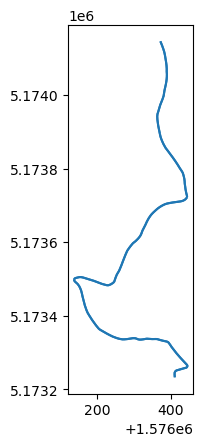

In [33]:
strava_id_map[strava_id_map["osmId"] == 23801087].plot()

Parsed 8 unique edge ids from cpaths for osm_id=23801087
id-map rows: 10
         osmid                                           geometry
455   23801087  LINESTRING (1576411.361 5173233.105, 1576410.8...
462   23801087  LINESTRING (1576398.058 5173322.696, 1576402.4...
463   23801087  LINESTRING (1576398.058 5173322.696, 1576395.7...
2409  23801087  LINESTRING (1576138.087 5173499.363, 1576137.8...
2410  23801087  LINESTRING (1576138.087 5173499.363, 1576138.9...


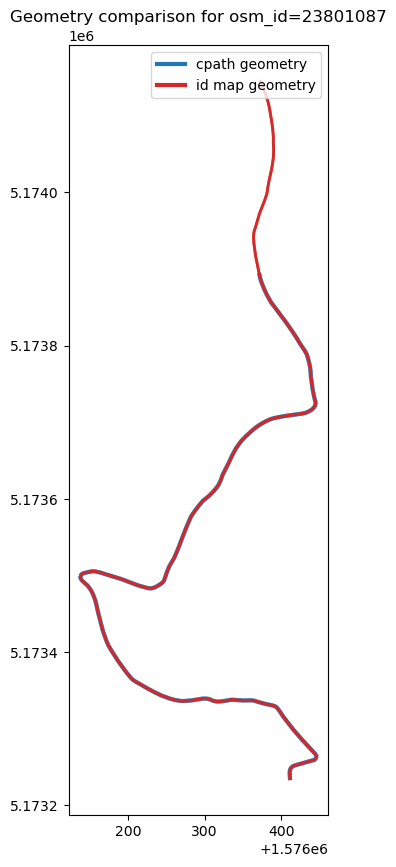

In [ ]:

def _parse_edge_ids(value):
    if isinstance(value, (list, tuple, set)):
        return list(value)
    if pd.isna(value):
        return []
    if isinstance(value, str):
        cleaned = value.strip().strip('[]')
        if not cleaned:
            return []
        parts = [part.strip().strip("'") for part in cleaned.split(',')]
        return [part for part in parts if part]
    return [value]


osm_id = 23801087

# Geometry suggested by cpaths
if 'osm_reference_id_num' in strava_counts.columns:
    strava_ref = pd.to_numeric(strava_counts['osm_reference_id_num'], errors='coerce').astype('Int64')
else:
    strava_ref = pd.to_numeric(strava_counts['osm_reference_id'], errors='coerce').astype('Int64')

strava_for_osm = strava_counts.loc[strava_ref == osm_id].copy()
if strava_for_osm.empty:
    raise ValueError(f'No Strava rows found for osm_id={osm_id}')

cpath_edge_ids = []
for value in strava_for_osm['cpath'].dropna():
    cpath_edge_ids.extend(_parse_edge_ids(value))

cpath_edge_ids = (
    pd.to_numeric(pd.Series(cpath_edge_ids), errors='coerce')
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)

if not cpath_edge_ids:
    raise ValueError(f'No edge ids could be parsed from cpaths for osm_id={osm_id}')

cpath_edges = edges.iloc[cpath_edge_ids].copy()

# Geometry suggested by the id map
id_map_match = strava_id_map.loc[pd.to_numeric(strava_id_map['osmId'], errors='coerce').astype('Int64') == osm_id].copy()
if id_map_match.empty:
    raise ValueError(f'No id-map geometry found for osmId={osm_id}')

fig, ax = plt.subplots(figsize=(10, 10))

cpath_edges.plot(ax=ax, color='tab:blue', linewidth=3, alpha=0.7, label='cpath geometry')
id_map_match.plot(ax=ax, color='tab:red', linewidth=2, alpha=0.9, label='id map geometry')

ax.set_title(f'Geometry comparison for osm_id={osm_id}')
ax.set_aspect('equal')

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='tab:blue', lw=3, label='cpath geometry'),
    Line2D([0], [0], color='tab:red', lw=3, label='id map geometry'),
], loc='best')

print(f'Parsed {len(cpath_edge_ids)} unique edge ids from cpaths for osm_id={osm_id}')
print(f'id-map rows: {len(id_map_match)}')
print(cpath_edges[['osmid', 'geometry']].head())
